In [1]:
import time

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

import numpy as np

from scipy.integrate import odeint

In [ ]:
import sys
sys.path.append("../..")

from lunanav.sim.rigid_body import rigid_body_derivative
from lunanav.sim.quaternion import angle_axis_to_q
from lunanav.plotting import plot_state_vector, debug_3d

In [3]:
def linearize(f, s, u):
    """Linearize the function `f(s, u)` around `(s, u)`.

    Arguments
    ---------
    f : callable
        A nonlinear function with call signature `f(s, u)`.
    s : numpy.ndarray
        The state (1-D).
    u : numpy.ndarray
        The control input (1-D).

    Returns
    -------
    A : numpy.ndarray
        The Jacobian of `f` at `(s, u)`, with respect to `s`.
    B : numpy.ndarray
        The Jacobian of `f` at `(s, u)`, with respect to `u`.
    """
    # WRITE YOUR CODE BELOW ###################################################
    # INSTRUCTIONS: Use JAX to compute `A` and `B` in one line.
    A,B = jax.jacobian(f, argnums=(0,1))(s, u)
    ###########################################################################
    return A, B

In [4]:
def ilqr(f, s0, s_goal, N, Q, R, QN, eps=1e-3, max_iters=1000):
    """Compute the iLQR set-point tracking solution.

    Arguments
    ---------
    f : callable
        A function describing the discrete-time dynamics, such that
        `s[k+1] = f(s[k], u[k])`.
    s0 : numpy.ndarray
        The initial state (1-D).
    s_goal : numpy.ndarray
        The goal state (1-D).
    N : int
        The time horizon of the LQR cost function.
    Q : numpy.ndarray
        The state cost matrix (2-D).
    R : numpy.ndarray
        The control cost matrix (2-D).
    QN : numpy.ndarray
        The terminal state cost matrix (2-D).
    eps : float, optional
        Termination threshold for iLQR.
    max_iters : int, optional
        Maximum number of iLQR iterations.

    Returns
    -------
    s_bar : numpy.ndarray
        A 2-D array where `s_bar[k]` is the nominal state at time step `k`,
        for `k = 0, 1, ..., N-1`
    u_bar : numpy.ndarray
        A 2-D array where `u_bar[k]` is the nominal control at time step `k`,
        for `k = 0, 1, ..., N-1`
    Y : numpy.ndarray
        A 3-D array where `Y[k]` is the matrix gain term of the iLQR control
        law at time step `k`, for `k = 0, 1, ..., N-1`
    y : numpy.ndarray
        A 2-D array where `y[k]` is the offset term of the iLQR control law
        at time step `k`, for `k = 0, 1, ..., N-1`
    """
    if max_iters <= 1:
        raise ValueError("Argument `max_iters` must be at least 1.")
    n = Q.shape[0]  # state dimension
    m = R.shape[0]  # control dimension

    # Initialize gains `Y` and offsets `y` for the policy
    Y = np.zeros((N, m, n))
    y = np.zeros((N, m))

    # Initialize the nominal trajectory `(s_bar, u_bar`), and the
    # deviations `(ds, du)`
    u_bar = np.zeros((N, m))
    s_bar = np.zeros((N + 1, n))
    s_bar[0] = s0
    for k in range(N):
        s_bar[k + 1] = f(s_bar[k], u_bar[k])
    ds = np.zeros((N + 1, n))
    du = np.zeros((N, m))

    # iLQR loop
    converged = False
    for _ in range(max_iters):

        # PART (c) ############################################################

        # Linearize the dynamics at each step `k` of `(s_bar, u_bar)`
        A, B = jax.vmap(linearize, in_axes=(None, 0, 0))(f, s_bar[:-1], u_bar)
        A, B = np.array(A), np.array(B)

        ds = np.zeros_like(ds)
        du = np.zeros_like(du)
        
        # 1. Backward pass
        P = np.zeros((N + 1, n, n))
        p = np.zeros((N + 1, n))
        
        q_N = QN @ (s_bar[N] - s_goal) # From part (b)
        
        P[N] = QN
        p[N] = q_N

        for k in range(N-1, -1, -1):
            H_xu = A[k].T @ P[k+1] @ B[k]
            H_xx = Q + A[k].T @ P[k+1] @ A[k]
            H_uu = R + B[k].T @ P[k+1] @ B[k]

            q_k = Q @ (s_bar[k] - s_goal) # From part (b)
            r_k = R @ u_bar[k] # From part (b)

            h_x = q_k + A[k].T @ p[k+1]
            h_u = r_k + B[k].T @ p[k+1]

            Y[k] = -np.linalg.pinv(H_uu) @ H_xu.T
            y[k] = -np.linalg.pinv(H_uu) @ h_u
            
            P[k] = H_xx + H_xu @ Y[k]
            p[k] = h_x + H_xu @ y[k]



        # Forward pass
        for k in range(N):
            du[k] = y[k] + Y[k] @ ds[k]
            ds[k+1] = f(s_bar[k] + ds[k], u_bar[k] + du[k]) - s_bar[k+1]


        s_bar = s_bar + ds
        u_bar = u_bar + du
        
        #######################################################################

        if np.max(np.abs(du)) < eps:
            converged = True
            break
    if not converged:
        raise RuntimeError("iLQR did not converge!")
    return s_bar, u_bar, Y, y

In [5]:
# Define constants
n = 13  # state dimension
m = 6  # control dimension
Q = np.eye(n)  # state cost matrix
R = 1e-2 * np.eye(m)  # control cost matrix
QN = 1e2 * np.eye(n)  # terminal state cost matrix

T = 10.0  # simulation time
dt = 0.1  # sampling time


In [6]:
mass = 5 # kg
I = 5 * np.eye(3)

In [7]:
s0 = np.array([
    0,-100, 100, 
    0 ,0, 0,
    *angle_axis_to_q(90, [1,0,0], True),
    0,0,0])

print(f"Initial state: {s0}")


s_goal = np.array([
    0,0, 0, 
    0 ,0, 0,
    1,0,0,0,
    0,0,0])

Initial state: [   0.         -100.          100.            0.            0.
    0.            0.70710678    0.70710678    0.            0.
    0.            0.            0.        ]


In [8]:
# Initialize continuous-time and discretized dynamics
# t: float, state: jnp.ndarray, disturbances: jnp.ndarray, mass_kg: float, I: np.ndarray):
def deriv_wrapper(s, u):
    return rigid_body_derivative(0, s, u, mass, I)
    
f = jax.jit(deriv_wrapper)
fd = jax.jit(lambda s, u, dt=dt: s + dt * f(s, u))

In [9]:
print("Computing iLQR solution ... ", end="", flush=True)
start = time.time()
t = np.arange(0.0, T, dt)
N = t.size - 1
s_bar, u_bar, Y, y = ilqr(fd, s0, s_goal, N, Q, R, QN)
print("done! ({:.2f} s)".format(time.time() - start), flush=True)

Computing iLQR solution ... done! (2.01 s)


In [10]:

# Simulate on the true continuous-time system
print("Simulating ... ", end="", flush=True)
start = time.time()
s = np.zeros((N + 1, n))
u = np.zeros((N, m))
s[0] = s0
for k in range(N):
    # PART (d) ################################################################
    # INSTRUCTIONS: Compute either the closed-loop or open-loop value of
    # `u[k]`, depending on the Boolean flag `closed_loop`.
    if True:
        u[k] = u_bar[k] + Y[k]@(s[k] - s_bar[k]) + y[k]
        # raise NotImplementedError()
    else:  # do open-loop control
        u[k] = u_bar[k]
        
    ###########################################################################
    s[k + 1] = odeint(lambda s, t: f(s, u[k]), s[k], t[k : k + 2])[1]
print("done! ({:.2f} s)".format(time.time() - start), flush=True)

Simulating ... done! (0.22 s)


/Users/magi-nerv/Space-Specifically/Stanford/AA278/lunar-pnt-sim/tests/../lunanav/plotting.py:222: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


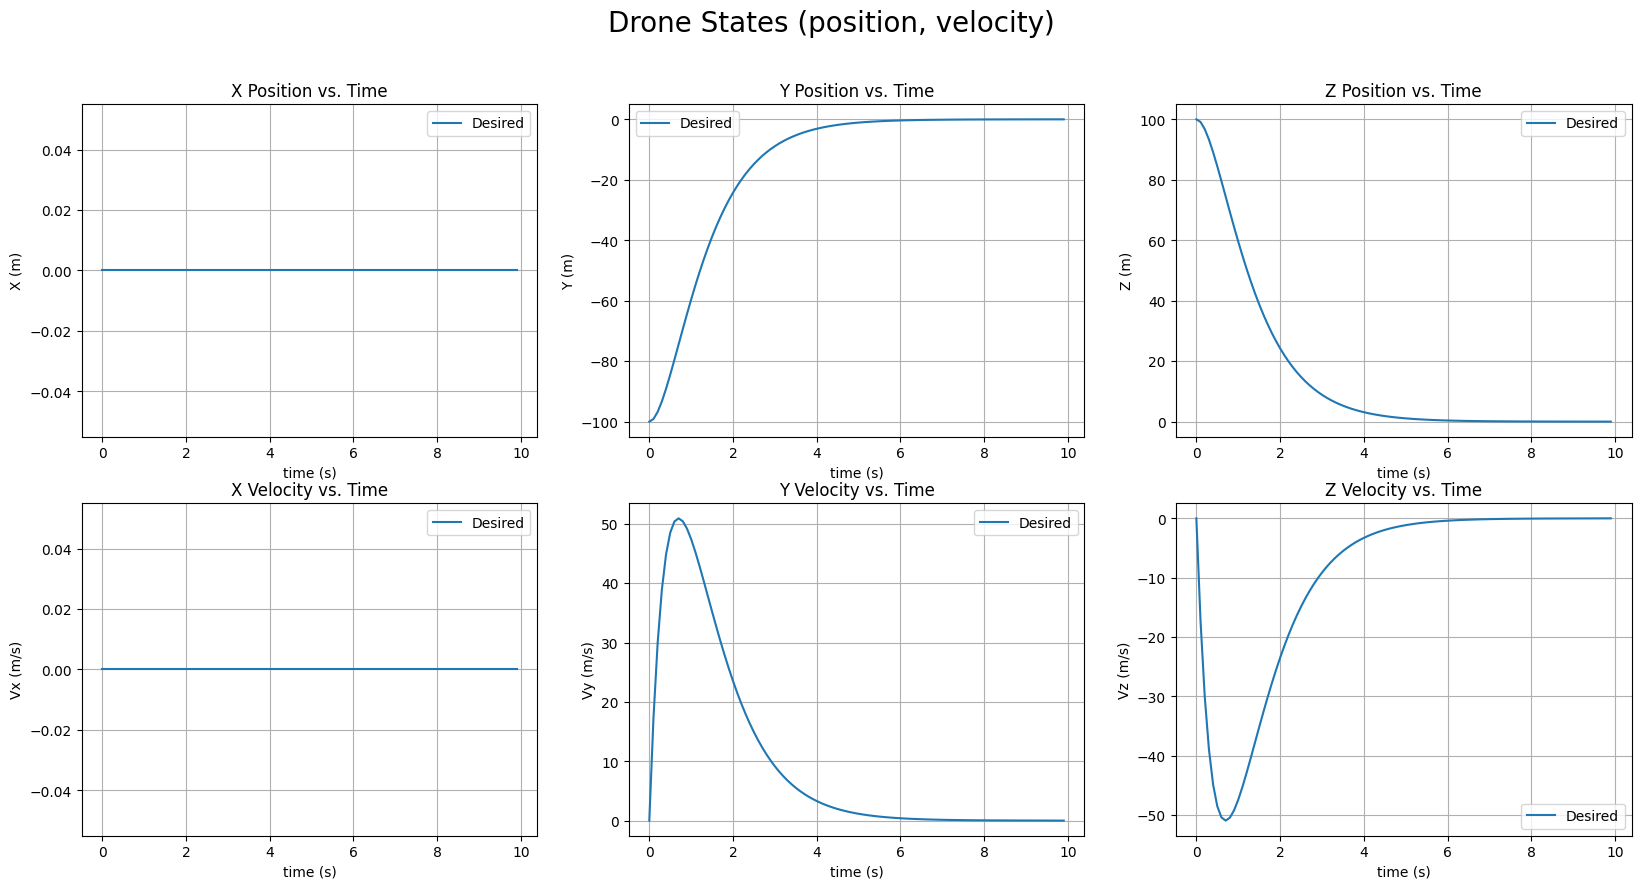

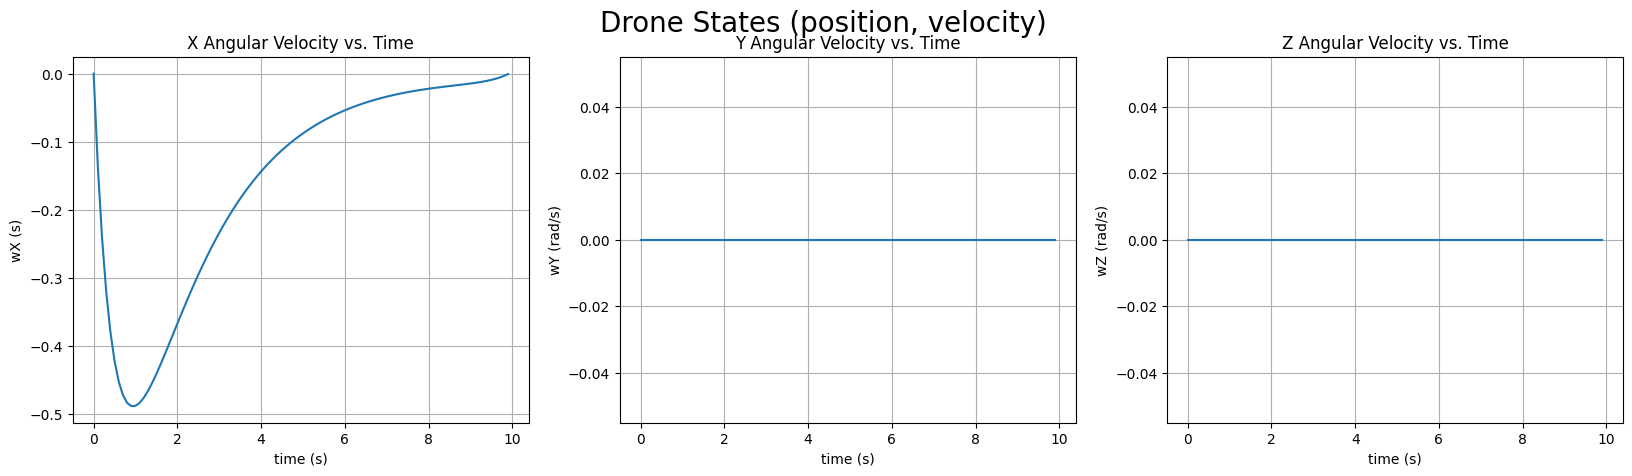

In [14]:
plot_state_vector(t, s)

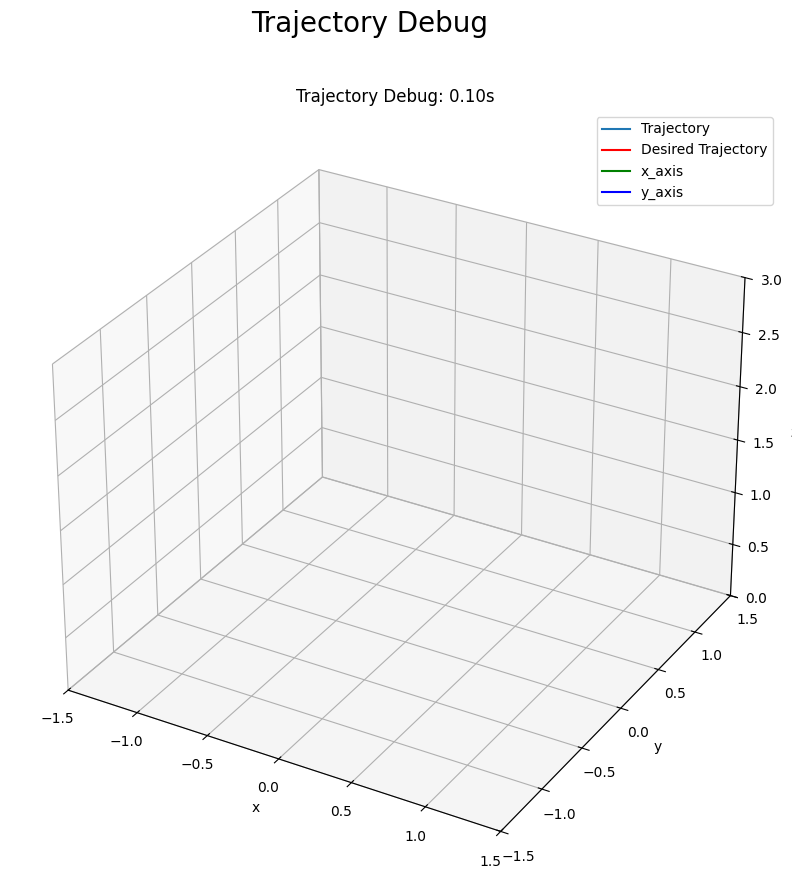

In [27]:
limits = np.array([
    [-10, 10],
    [-110, 10],
    [-10, 110]
])

debug_3d(s, t, dt)

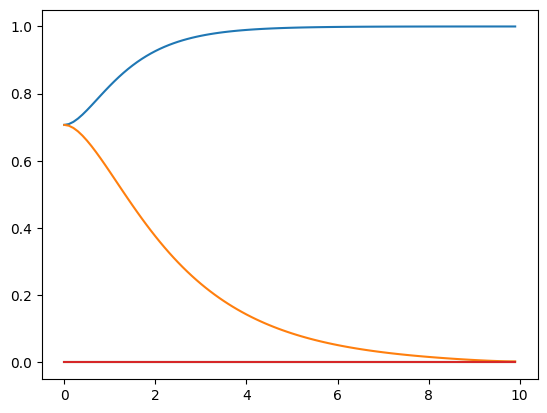

In [15]:
plt.plot(t, s[:,6:10])